In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score)

In [54]:
df = pd.read_csv("../data/processed/feature_engineering_data.csv")
df.head()

,Date,Year,Month,Price_alum,Price_gold,Price_nickel,Price_silver,Price_uran,Inflation_rate,Price_alum_infl,...,Price_nickel_Lag_1,Price_nickel_Lag_2,Price_nickel_Lag_3,Price_nickel_Rolling_Mean_3,Price_nickel_Returns,Price_uran_Lag_1,Price_uran_Lag_2,Price_uran_Lag_3,Price_uran_Rolling_Mean_3,Price_uran_Returns
0,1992-05-01,1992,May,1306.79,337.24,7326.8,4.07,7.55,89.59,2477.543161,...,7420.6,7417.7,7861.9,7388.366667,-0.012640,7.75,7.75,7.90,7.683333,-0.025806
1,1992-06-01,1992,Jun,1275.55,340.81,7192.8,4.06,7.75,89.59,2418.315245,...,7326.8,7420.6,7417.7,7313.400000,-0.018289,7.55,7.75,7.75,7.683333,0.026490
2,1992-07-01,1992,Jul,1313.05,352.72,7497.9,3.97,7.75,89.59,2489.411495,...,7192.8,7326.8,7420.6,7339.166667,0.042417,7.75,7.55,7.75,7.683333,0.000000
3,1992-08-01,1992,Aug,1305.05,343.06,7268.0,3.81,8.05,89.59,2474.244295,...,7497.9,7192.8,7326.8,7319.566667,-0.030662,7.75,7.75,7.55,7.850000,0.038710
4,1992-09-01,1992,Sep,1269.61,345.43,6917.5,3.77,8.75,89.59,2407.053599,...,7268.0,7497.9,7192.8,7227.800000,-0.048225,8.05,7.75,7.75,8.183333,0.086957


In [55]:
metals = ["Price_gold", "Price_silver", "Price_alum","Price_uran", "Price_nickel" ]

Features and Target

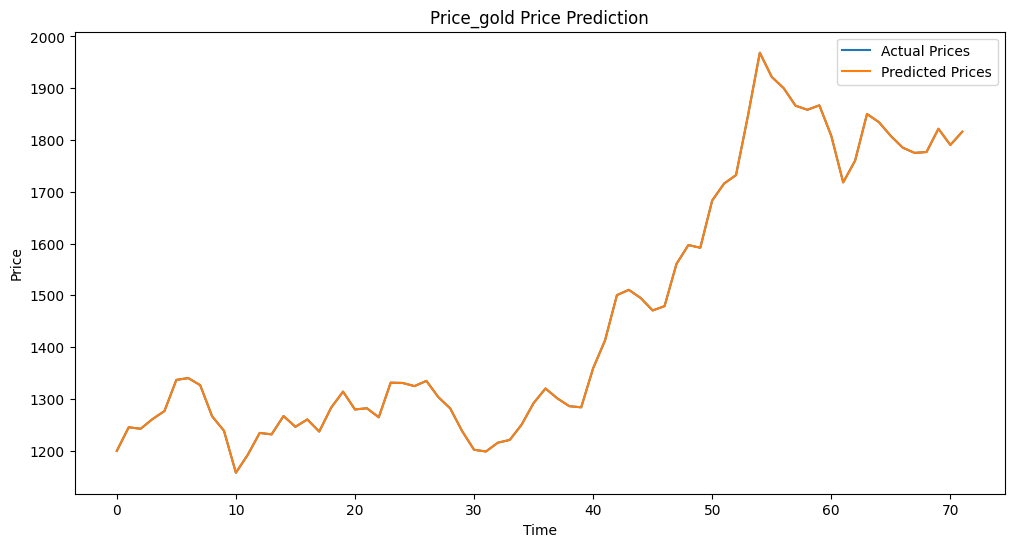


Results for Price_gold
MAE: 2.1884716261411086e-12
RMSE: 2.4656913623808474e-12
R2: 1.0


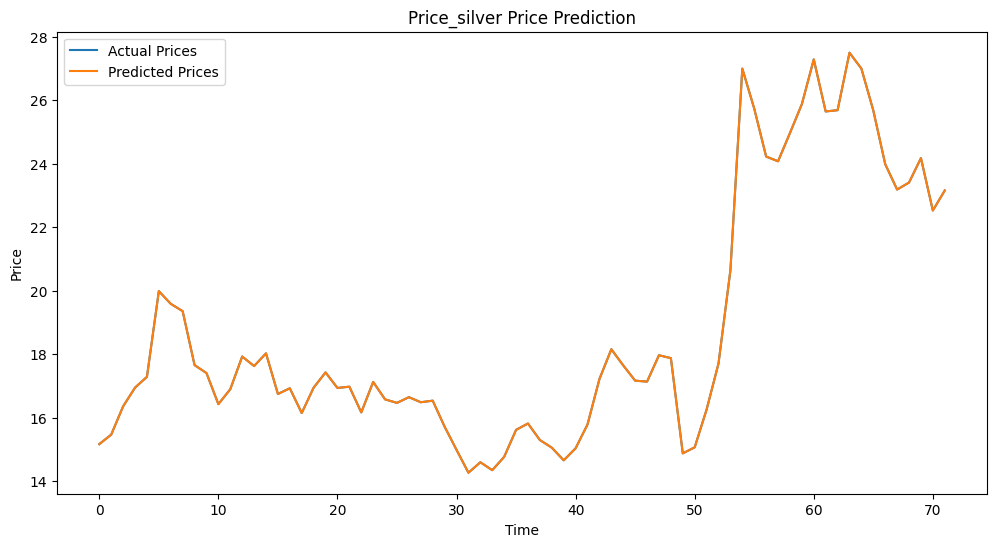


Results for Price_silver
MAE: 1.84297022087776e-14
RMSE: 1.9817195916237166e-14
R2: 1.0


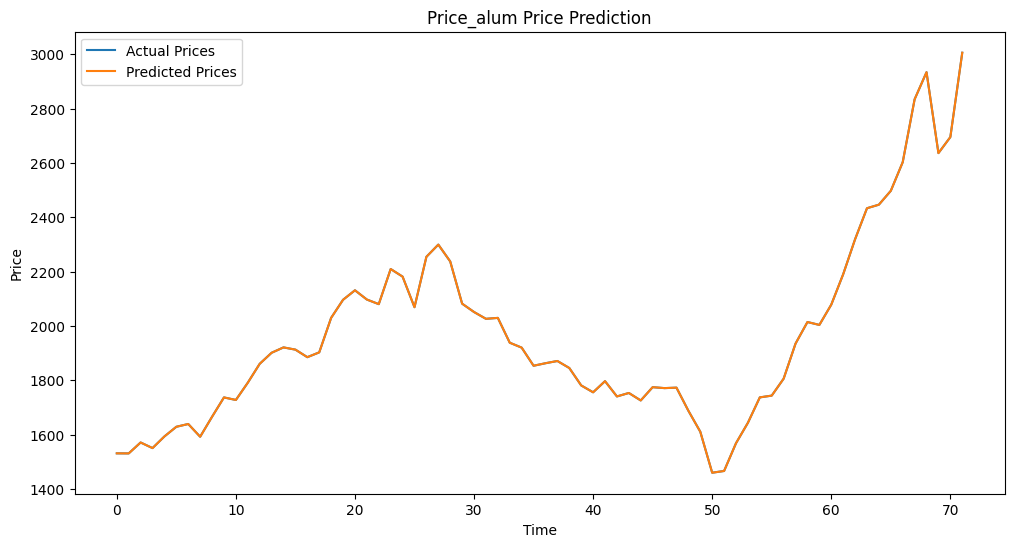


Results for Price_alum
MAE: 2.6874305250304234e-12
RMSE: 3.300509887092203e-12
R2: 1.0


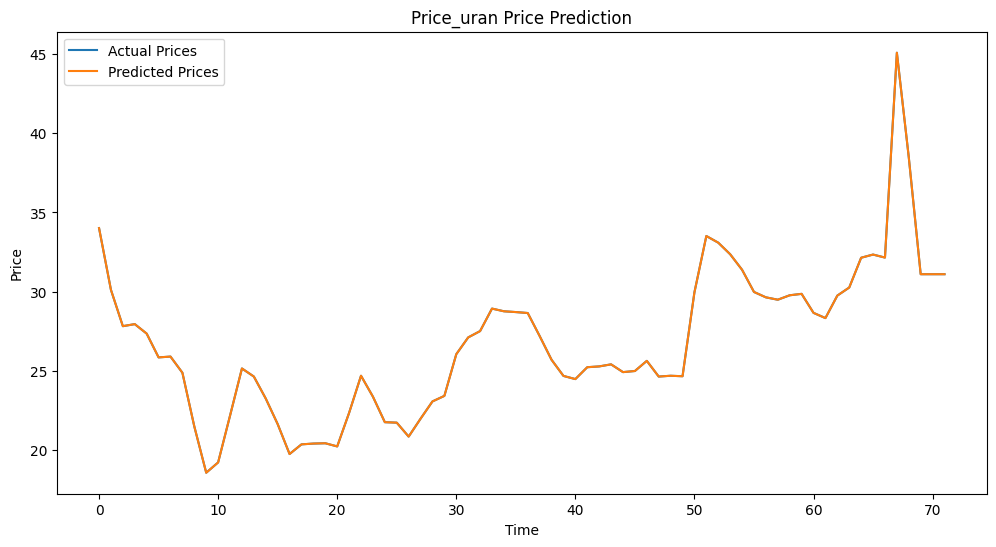


Results for Price_uran
MAE: 1.554312234475219e-14
RMSE: 1.7719103822653185e-14
R2: 1.0


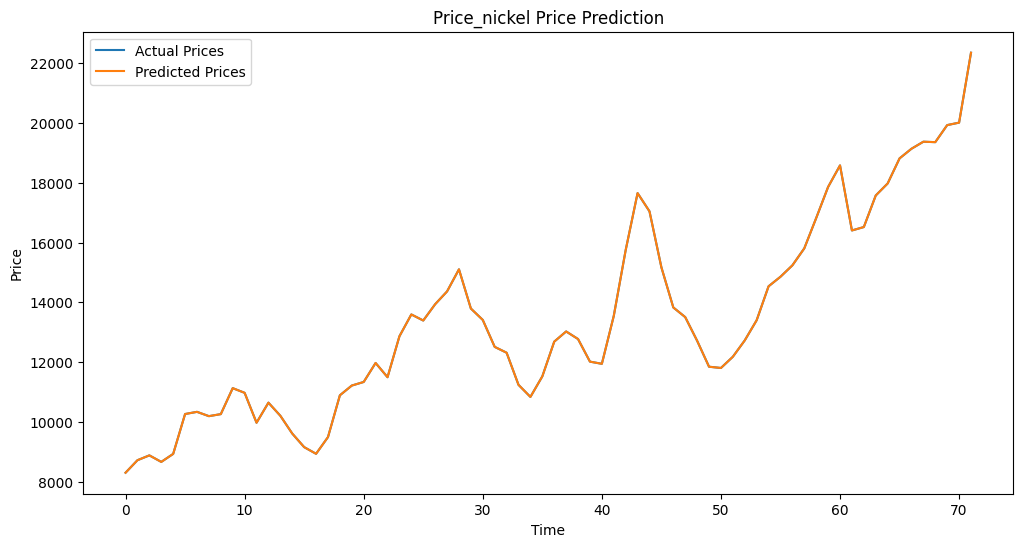


Results for Price_nickel
MAE: 1.3895057943753071e-11
RMSE: 1.4814809792818918e-11
R2: 1.0


In [56]:
lr_results = []
for metal in metals:
    # Features
    X = df[
        [
            "Year",
            "Month_Num",
            "Quarter",

            f"{metal}_Lag_1",
            f"{metal}_Lag_2",
            f"{metal}_Lag_3",

            f"{metal}_Rolling_Mean_3"
        ]
    ]
 
    # Target
    y = df[metal]

    # Train Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # Linear Regression Model
    lr_model = LinearRegression()

    # Model Training
    lr_model.fit(X_train, y_train)

    #Predictions
    predictions = lr_model.predict(X_test)

    # Visualization
    plt.figure(figsize=(12,6))

    plt.plot(
        y_test.values,
        label="Actual Prices"
    )

    plt.plot(
        predictions,
        label="Predicted Prices"
    )

    plt.title(f"{metal} Price Prediction")

    plt.xlabel("Time")

    plt.ylabel("Price")

    plt.legend()

    plt.show()

    #Evaluation Metrics

    # MAE - Mean Absolute Error
    mae = mean_absolute_error(
        y_test,
        predictions
    )
    # RMSE - Root Mean Squared Error
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
    # R2 Score
    r2 = r2_score(
        y_test,
        predictions
    )

    # Store results
    lr_results.append({
        "Metal": metal,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    # Print results
    print(f"\nResults for {metal}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    

Linear Regression model plot shows overlapping of Actual and Predicted values that means the model predictions are close to real prices

In [57]:
results_df = pd.DataFrame(lr_results)

print(results_df)

          Metal           MAE          RMSE  R2 Score
0    Price_gold  2.188472e-12  2.465691e-12       1.0
1  Price_silver  1.842970e-14  1.981720e-14       1.0
2    Price_alum  2.687431e-12  3.300510e-12       1.0
3    Price_uran  1.554312e-14  1.771910e-14       1.0
4  Price_nickel  1.389506e-11  1.481481e-11       1.0


Random Forest

MAE: 54.502226388888886
RMSE: 80.83963548973132
R2 Score: 0.8951309842362948


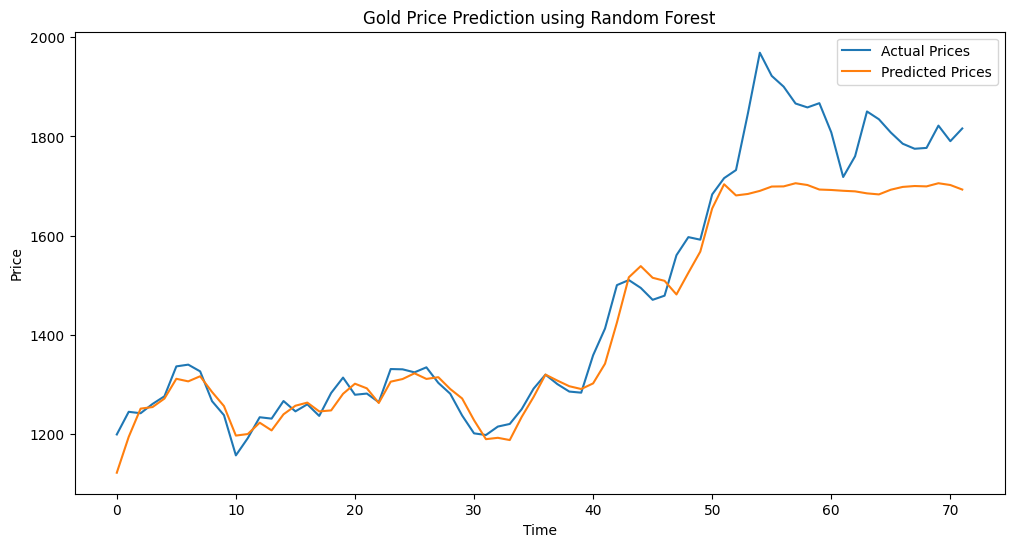

MAE: 0.7032666666666686
RMSE: 1.0469421456741974
R2 Score: 0.928100490024086


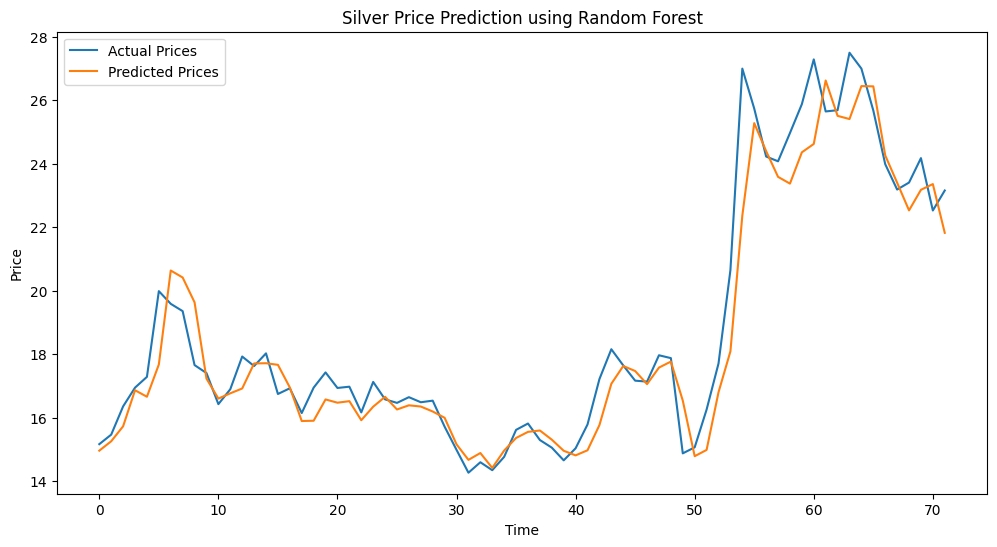

MAE: 47.04125138888894
RMSE: 70.31062431862529
R2 Score: 0.9584345544673151


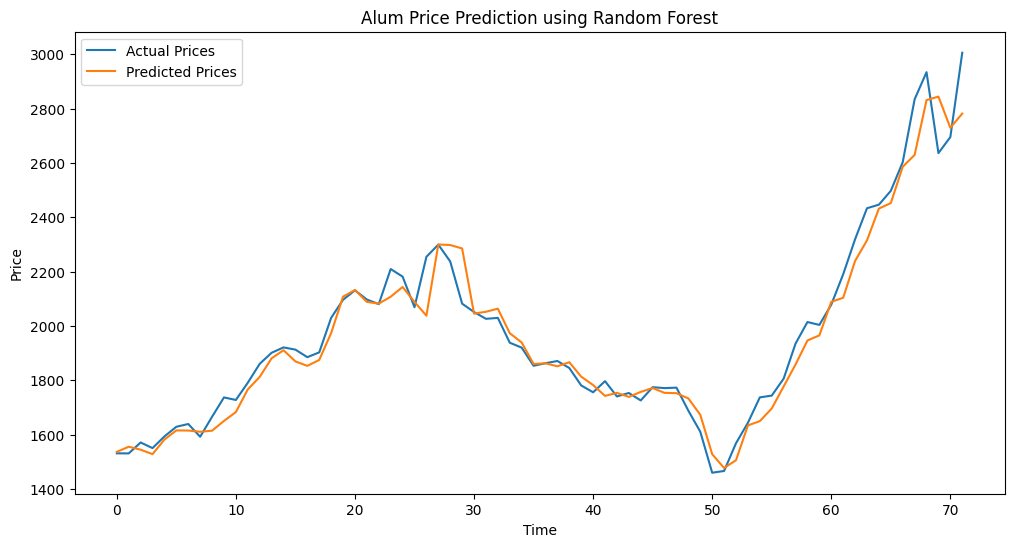

MAE: 2.797402777777776
RMSE: 3.4474588703533176
R2 Score: 0.453588450079642


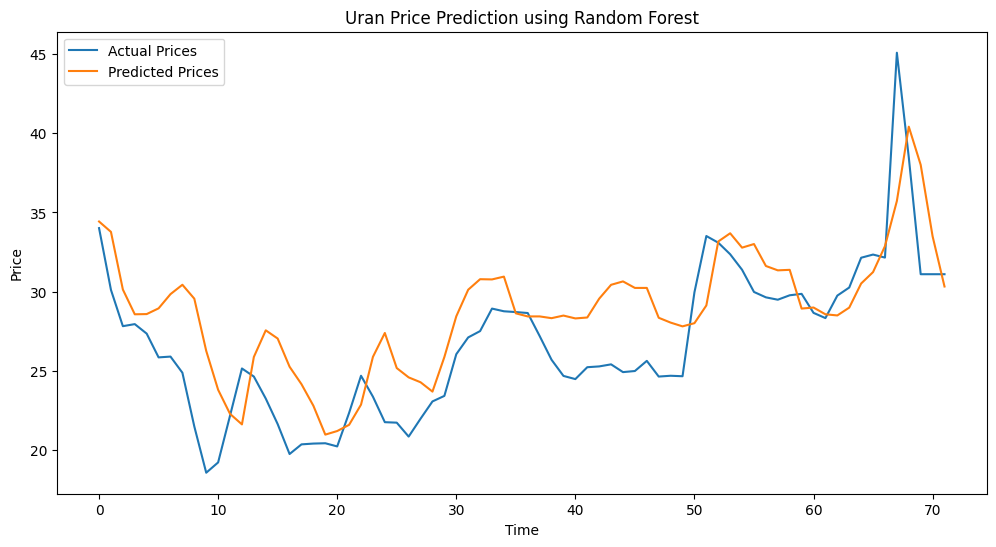

MAE: 514.1589638888883
RMSE: 651.9155170990578
R2 Score: 0.960876472750967


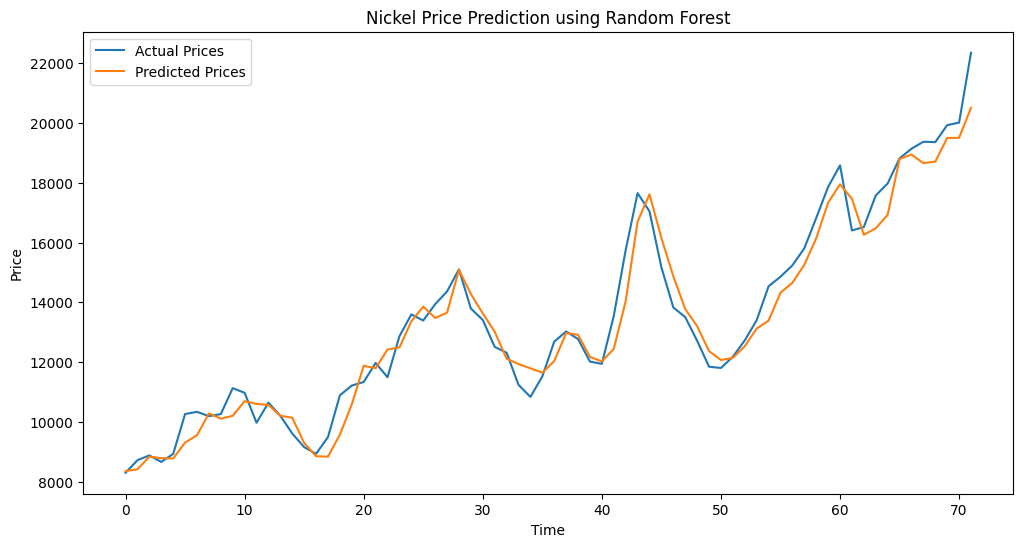

In [58]:
rf_results = []

for metal in metals:
    #features
    X = df[
        [
            "Year",
            "Month_Num",
            "Quarter",

            f"{metal}_Lag_1",
            f"{metal}_Lag_2",
            f"{metal}_Lag_3",

            f"{metal}_Rolling_Mean_3"
        ]
    ]
    #target
    y = df[metal]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # Random Forest Regressor

    rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

    rf_model.fit(X_train, y_train)

    #Predictions
    rf_predictions = rf_model.predict(X_test)

    #Evaluation Metrics
    # MAE - Mean Absolute Error
    mae = mean_absolute_error(
        y_test,
        rf_predictions
    )

    # RMSE - Root Mean Squared Error
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            rf_predictions
        )
    )
    # R2 Score
    r2 = r2_score(
        y_test,
        rf_predictions
    )
    # PRINT RESULTS
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

    rf_results.append({
        "Metal": metal,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    # Visualization
    clean_name = metal.replace(
        "Price_",
        ""
    ).capitalize()

    plt.figure(figsize=(12,6))

    plt.plot(
        y_test.values,
        label="Actual Prices"
    )

    plt.plot(
        rf_predictions,
        label="Predicted Prices"
    )

    plt.title(
        f"{clean_name} Price Prediction using Random Forest"
    )

    plt.xlabel("Time")

    plt.ylabel("Price")

    plt.legend()

    plt.show()




In [59]:
results_df = pd.DataFrame(results)


print(results_df)

          Metal         MAE        RMSE  R2 Score
0    Price_gold   54.502226   80.839635  0.895131
1  Price_silver    0.703267    1.046942  0.928100
2    Price_alum   47.041251   70.310624  0.958435
3    Price_uran    2.797403    3.447459  0.453588
4  Price_nickel  514.158964  651.915517  0.960876


The Random Forest model effectively captured nonlinear trends and medium-term market movements in gold prices. However, the model struggled to predict sudden price surges during highly volatile market periods, indicating the limitations of tree-based ensemble models in extrapolating unseen financial extremes.

Comparison between Linear Regression and Random Forest 

In [60]:
lr_df = pd.DataFrame(lr_results)

rf_df = pd.DataFrame(rf_results)

In [61]:
comparison_df = pd.concat(
    [lr_df, rf_df],
    ignore_index=True
)

In [62]:
print(comparison_df)

          Metal           MAE          RMSE  R2 Score
0    Price_gold  2.188472e-12  2.465691e-12  1.000000
1  Price_silver  1.842970e-14  1.981720e-14  1.000000
2    Price_alum  2.687431e-12  3.300510e-12  1.000000
3    Price_uran  1.554312e-14  1.771910e-14  1.000000
4  Price_nickel  1.389506e-11  1.481481e-11  1.000000
5    Price_gold  5.450223e+01  8.083964e+01  0.895131
6  Price_silver  7.032667e-01  1.046942e+00  0.928100
7    Price_alum  4.704125e+01  7.031062e+01  0.958435
8    Price_uran  2.797403e+00  3.447459e+00  0.453588
9  Price_nickel  5.141590e+02  6.519155e+02  0.960876


Best Model Identification

In [63]:
best_models = comparison_df.loc[
    comparison_df.groupby("Metal")["R2 Score"].idxmax()
]

print(best_models)

          Metal           MAE          RMSE  R2 Score
2    Price_alum  2.687431e-12  3.300510e-12       1.0
0    Price_gold  2.188472e-12  2.465691e-12       1.0
4  Price_nickel  1.389506e-11  1.481481e-11       1.0
1  Price_silver  1.842970e-14  1.981720e-14       1.0
3    Price_uran  1.554312e-14  1.771910e-14       1.0
